Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5
Epoch 1/50


/Users/lasseleekrogshave/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5485 - loss: 1.2908 - val_accuracy: 0.8623 - val_loss: 0.4151
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.8828 - loss: 0.3575 - val_accuracy: 0.9203 - val_loss: 0.2577
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - accuracy: 0.9234 - loss: 0.2384 - val_accuracy: 0.9372 - val_loss: 0.1991
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.9420 - loss: 0.1635 - val_accuracy: 0.9469 - val_loss: 0.1913
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - accuracy: 0.9583 - loss: 0.1363 - val_accuracy: 0.9541 - val_loss: 0.1471
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - accuracy: 0.9505 - loss: 0.1173 - val_accuracy: 0.9565 - val_loss: 0.1422
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.9639 - loss: 0.0974 - val_accuracy: 0.9589 - val_loss: 0.1283
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.9767 - loss: 0.0755 - val_accuracy: 0.9614 - val_lo

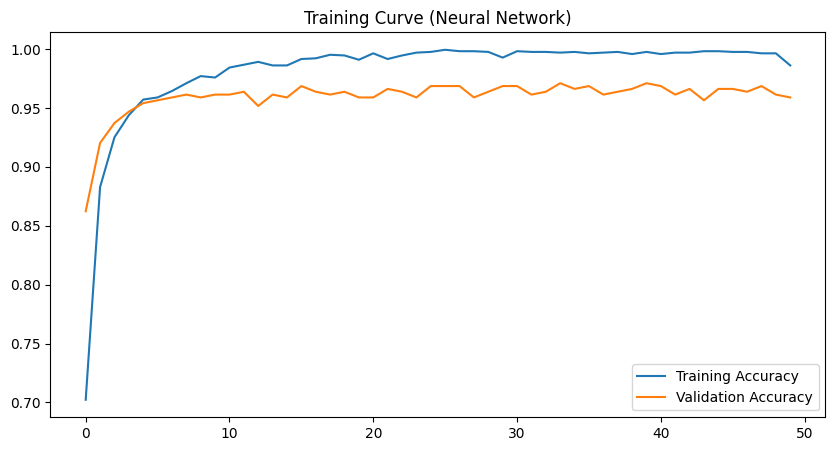

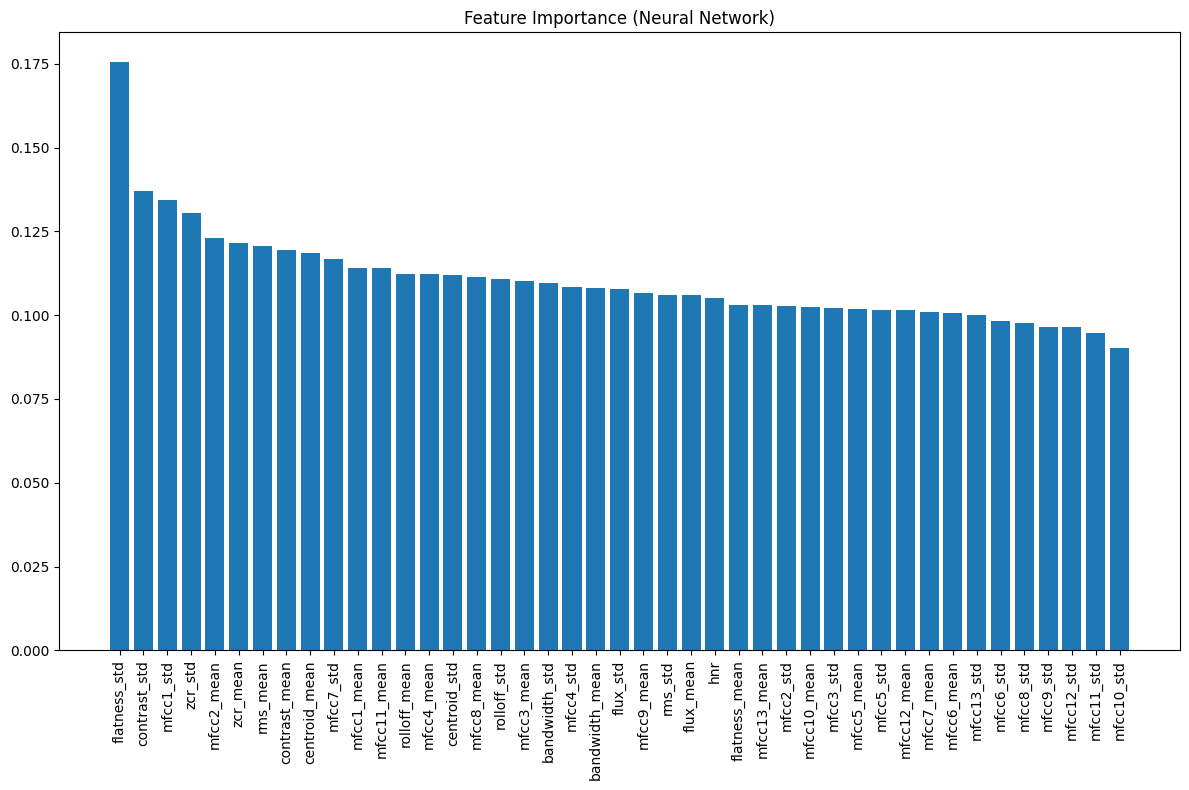


Top 15 vigtigste features:
flatness_std: 0.1756
contrast_std: 0.1371
mfcc1_std: 0.1344
zcr_std: 0.1304
mfcc2_mean: 0.1231
zcr_mean: 0.1216
rms_mean: 0.1205
contrast_mean: 0.1194
centroid_mean: 0.1186
mfcc7_std: 0.1168
mfcc1_mean: 0.1142
mfcc11_mean: 0.1141
rolloff_mean: 0.1123
mfcc4_mean: 0.1121
centroid_std: 0.1121


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    tf = importlib.import_module("tensorflow")
    keras_api = tf.keras
except ImportError:
    keras_api = importlib.import_module("keras")

Sequential = keras_api.Sequential
Dense = keras_api.layers.Dense
Adam = keras_api.optimizers.Adam

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features fra training
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Klasse mapping:")
for i, class_name in enumerate(class_names):
    print(f"{class_name} -> {i}")

# Skalering (vigtigt for neural network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. NEURAL NETWORK MODEL
# ----------------------------
input_dim = X_train.shape[1]
num_classes = len(class_names)

model = Sequential()
model.add(Dense(128, input_dim=input_dim, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------
# 5. VALIDATION TRAINING
# ----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=class_names))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. LOAD TEST DATA
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# Fjern kun filnavn (behold beta og snr til error analysis)
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Features til modellen (fjern kun target, beta, snr)
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")
y_test_true = label_encoder.transform(df_test["target"])
X_test_scaled = scaler.transform(X_test)

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# ----------------------------
# 7. TEST EVALUATION
# ----------------------------
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)

print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Curve (Neural Network)")
plt.legend()
plt.show()

# ----------------------------
# 8. FEATURE IMPORTANCE
# ----------------------------
feature_names = X.columns

# Brug gennemsnitlig absolut vægt i første layer som feature-importance
first_layer_weights = model.layers[0].get_weights()[0]
importances = np.mean(np.abs(first_layer_weights), axis=1)

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (Neural Network)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54820/4238617168.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


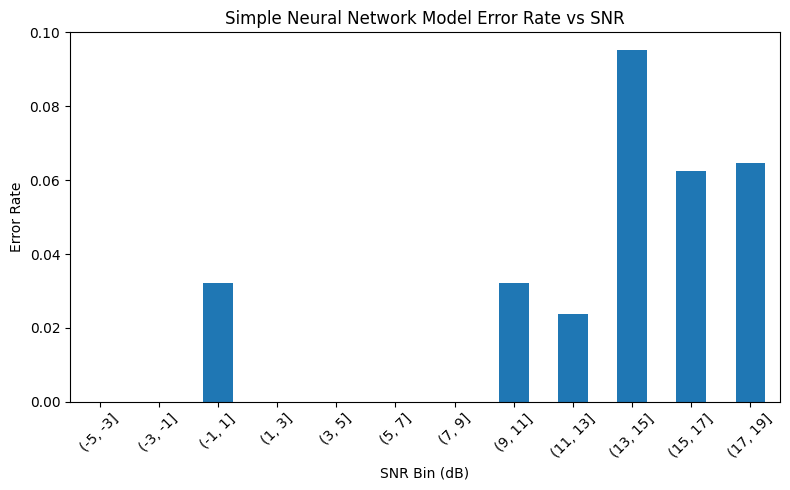

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54820/4238617168.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


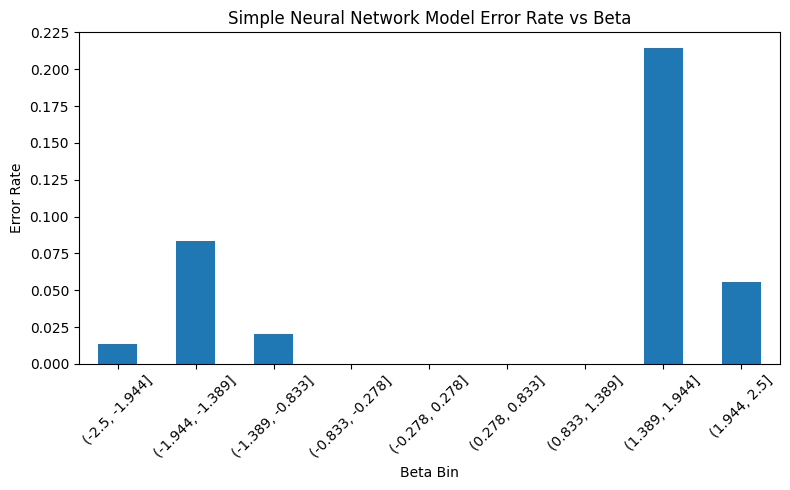


Eksempler på fejl:
     true_label   pred_label  beta  snr_db
27    BlueNoise        Clean -0.95   18.41
76    BlueNoise  VioletNoise -1.05   16.49
102  BrownNoise  VioletNoise  1.90   14.98
111  BrownNoise  VioletNoise  1.92   19.10
112  BrownNoise        Clean  1.92   19.58
114  BrownNoise        Clean  1.93   14.01
116  BrownNoise        Clean  1.93   15.69
123  BrownNoise        Clean  1.94   15.79
143  BrownNoise        Clean  1.97   19.00
169  BrownNoise        Clean  2.04   13.71
172  BrownNoise        Clean  2.04   19.85
176  BrownNoise        Clean  2.05   14.09
200       Clean   BrownNoise   NaN     NaN
206       Clean  VioletNoise   NaN     NaN
218       Clean   BrownNoise   NaN     NaN
229       Clean   BrownNoise   NaN     NaN
234       Clean   BrownNoise   NaN     NaN
244       Clean   BrownNoise   NaN     NaN
265       Clean   BrownNoise   NaN     NaN
272       Clean  VioletNoise   NaN     NaN


In [4]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# Gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# ----------------------------
# Fejlrate vs SNR
# ----------------------------
# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()

snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

# Beregn fejlrate pr SNR-bin
snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("Simple Neural Network Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------
# Fejlrate vs Beta
# ----------------------------
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("Simple Neural Network Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------
# Eksempler på fejl
# ----------------------------
df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))